# VAE + Diffusion Map Exploration

This notebook trains a variational autoencoder (VAE) on XY-model lattice configurations and then applies diffusion maps to the learned latent codes to probe emergent structure.


## Workflow

1. Load XY configurations and metadata, converting spin angles to `(cos, sin)` pairs for smoother learning.
2. Train a lightweight PyTorch VAE on the configurations.
3. Encode every configuration to its latent mean.
4. Run a diffusion map on the latent samples and visualize the diffusion coordinates versus temperature/sector labels.


In [1]:
import csv
import pathlib
from typing import Tuple

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

try:
    import torch
    from torch import nn
    from torch.utils.data import Dataset, DataLoader
except ImportError as exc:  # pragma: no cover
    raise ImportError(
        "PyTorch is required for this notebook. Install with `pip install torch`."
    ) from exc

plt.style.use('seaborn-v0_8')
np.set_printoptions(precision=4, suppress=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
RNG = np.random.default_rng(42)


Using device: cuda


In [12]:
data_dir = pathlib.Path('.').resolve()
config_path = data_dir / 'xy_model_configurations.npy'
metadata_path = data_dir / 'xy_model_metadata.csv'

configs = np.load(config_path).astype(np.float32)
print(f"Configurations shape: {configs.shape}")

rows = []
with metadata_path.open() as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append(row)

if len(rows) != configs.shape[0]:
    raise ValueError("Metadata and configuration counts do not match.")

temperatures = np.array([float(r['temperature']) for r in rows], dtype=np.float32)
sectors = np.array([r['sector_label'].strip() for r in rows])
print(f"Loaded {len(rows)} metadata rows. Temperature range: {temperatures.min():.3f}–{temperatures.max():.3f}")


Configurations shape: (1200, 10000)
Loaded 1200 metadata rows. Temperature range: 0.100–1.200


In [13]:
def angles_to_xy(theta: np.ndarray) -> np.ndarray:
    """Map spin angles to concatenated (cos, sin) features."""
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    return np.concatenate([cos_theta, sin_theta], axis=1).astype(np.float32)

spin_features = angles_to_xy(configs)
temperature_feature = temperatures[:, None]
features = np.concatenate([spin_features, temperature_feature], axis=1)
print(f"Spin feature shape: {spin_features.shape}")
print(f"Augmented feature shape (with T): {features.shape}")

n_samples = features.shape[0]
train_ratio = 0.8
train_size = int(train_ratio * n_samples)
permutation = RNG.permutation(n_samples)
train_idx = permutation[:train_size]
val_idx = permutation[train_size:]

X_train = features[train_idx]
X_val = features[val_idx]
print(f"Train/val split: {X_train.shape[0]} / {X_val.shape[0]}")

class ArrayDataset(Dataset):
    def __init__(self, array: np.ndarray):
        self.tensor = torch.from_numpy(array)

    def __len__(self) -> int:
        return self.tensor.shape[0]

    def __getitem__(self, idx: int) -> torch.Tensor:
        return self.tensor[idx]

batch_size = 512
train_loader = DataLoader(ArrayDataset(X_train), batch_size=batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(ArrayDataset(X_val), batch_size=batch_size, shuffle=False, drop_last=False)
full_loader = DataLoader(ArrayDataset(features), batch_size=batch_size, shuffle=False, drop_last=False)


Spin feature shape: (1200, 20000)
Augmented feature shape (with T): (1200, 20001)
Train/val split: 960 / 240


In [14]:
class VAE(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int = 8, hidden_dims: Tuple[int, ...] = (512, 256, 128)):
        super().__init__()
        encoder_layers = []
        last_dim = input_dim
        for h in hidden_dims:
            encoder_layers.append(nn.Linear(last_dim, h))
            encoder_layers.append(nn.ReLU())
            last_dim = h
        self.encoder = nn.Sequential(*encoder_layers)
        self.fc_mu = nn.Linear(last_dim, latent_dim)
        self.fc_logvar = nn.Linear(last_dim, latent_dim)

        decoder_layers = []
        last_dim = latent_dim
        for h in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(last_dim, h))
            decoder_layers.append(nn.ReLU())
            last_dim = h
        decoder_layers.append(nn.Linear(last_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z)

    def forward(self, x: torch.Tensor):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

def vae_loss(recon_x, x, mu, logvar, beta: float = 1.0):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='mean')
    kld_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kld_loss, recon_loss.detach(), kld_loss.detach()

input_dim = features.shape[1]
latent_dim = 8
vae = VAE(input_dim, latent_dim=latent_dim).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
print(vae)


VAE(
  (encoder): Sequential(
    (0): Linear(in_features=20001, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
  )
  (fc_mu): Linear(in_features=128, out_features=8, bias=True)
  (fc_logvar): Linear(in_features=128, out_features=8, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=20001, bias=True)
  )
)


In [5]:
n_epochs = 50
beta = 1e-3  # balances KLD vs reconstruction
history = {'train_loss': [], 'val_loss': [], 'train_recon': [], 'val_recon': []}

for epoch in range(1, n_epochs + 1):
    vae.train()
    train_losses = []
    train_recon = []
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = vae(batch)
        loss, recon_loss, kld_loss = vae_loss(recon, batch, mu, logvar, beta=beta)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.detach().item())
        train_recon.append(recon_loss.item())

    vae.eval()
    val_losses = []
    val_recon = []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            recon, mu, logvar = vae(batch)
            loss, recon_loss, _ = vae_loss(recon, batch, mu, logvar, beta=beta)
            val_losses.append(loss.item())
            val_recon.append(recon_loss.item())

    history['train_loss'].append(float(np.mean(train_losses)))
    history['val_loss'].append(float(np.mean(val_losses)))
    history['train_recon'].append(float(np.mean(train_recon)))
    history['val_recon'].append(float(np.mean(val_recon)))

    print(f"Epoch {epoch:02d}: train={history['train_loss'][-1]:.4f}, val={history['val_loss'][-1]:.4f}")


Epoch 01: train=0.5018, val=0.5007
Epoch 02: train=0.5004, val=0.5004
Epoch 03: train=0.5001, val=0.5003
Epoch 04: train=0.4999, val=0.5003
Epoch 05: train=0.4996, val=0.5004
Epoch 06: train=0.4994, val=0.5003
Epoch 07: train=0.4990, val=0.4998
Epoch 08: train=0.4982, val=0.4988
Epoch 09: train=0.4965, val=0.4973
Epoch 10: train=0.4940, val=0.4953
Epoch 11: train=0.4906, val=0.4925
Epoch 12: train=0.4865, val=0.4895
Epoch 13: train=0.4824, val=0.4866
Epoch 14: train=0.4784, val=0.4840
Epoch 15: train=0.4752, val=0.4817
Epoch 16: train=0.4722, val=0.4796
Epoch 17: train=0.4695, val=0.4778
Epoch 18: train=0.4668, val=0.4757
Epoch 19: train=0.4644, val=0.4745
Epoch 20: train=0.4621, val=0.4731
Epoch 21: train=0.4599, val=0.4720
Epoch 22: train=0.4580, val=0.4706
Epoch 23: train=0.4559, val=0.4695
Epoch 24: train=0.4539, val=0.4687
Epoch 25: train=0.4525, val=0.4679
Epoch 26: train=0.4506, val=0.4679
Epoch 27: train=0.4493, val=0.4676
Epoch 28: train=0.4479, val=0.4674
Epoch 29: train=0.44

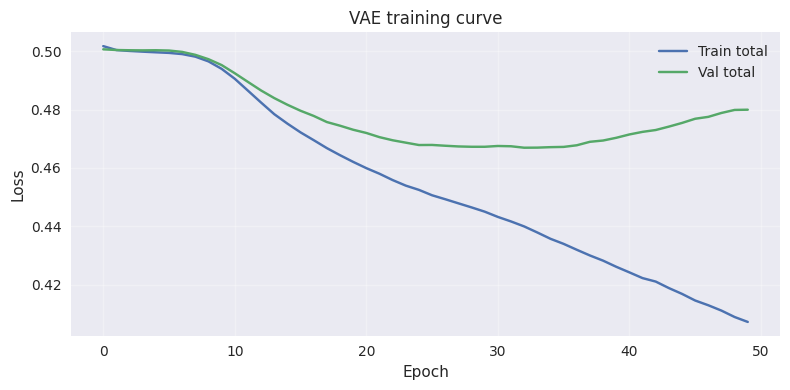

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='Train total')
plt.plot(history['val_loss'], label='Val total')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE training curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [7]:
vae.eval()
latents = []
with torch.no_grad():
    for batch in full_loader:
        batch = batch.to(device)
        mu, _ = vae.encode(batch)
        latents.append(mu.cpu().numpy())

latents = np.concatenate(latents, axis=0)
print(f"Latent matrix shape: {latents.shape}")


Latent matrix shape: (1200, 8)


In [8]:
def pairwise_sq_dists(X: np.ndarray) -> np.ndarray:
    norms = np.sum(X ** 2, axis=1, keepdims=True)
    dists = norms + norms.T - 2 * X @ X.T
    np.maximum(dists, 0.0, out=dists)
    return dists

def diffusion_map_embedding(X: np.ndarray, epsilon: float | None = None, n_dims: int = 3, diffusion_time: int = 1):
    n_samples = X.shape[0]
    dists = pairwise_sq_dists(X)
    if epsilon is None:
        triu = dists[np.triu_indices(n_samples, k=1)]
        epsilon = np.median(triu)
    epsilon = max(epsilon, 1e-8)
    K = np.exp(-dists / epsilon)
    row_sums = K.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    P = K / row_sums
    evals, evecs = np.linalg.eig(P.T)
    idx = np.argsort(-np.abs(evals))
    evals = np.real_if_close(evals[idx])
    evecs = np.real_if_close(evecs[:, idx])
    start = 1
    end = start + n_dims
    coords = evecs[:, start:end] * (evals[start:end] ** diffusion_time)
    return evals, coords


In [9]:
max_samples = 2500
n_total = latents.shape[0]
if n_total > max_samples:
    subset_idx = RNG.choice(n_total, size=max_samples, replace=False)
else:
    subset_idx = np.arange(n_total)

latent_subset = latents[subset_idx]
temp_subset = temperatures[subset_idx]
sector_subset = sectors[subset_idx]

print(f"Running diffusion maps on {latent_subset.shape[0]} latent vectors...")

evals, dm_coords = diffusion_map_embedding(latent_subset, n_dims=3, diffusion_time=1)
print("Top eigenvalues:", evals[:5])


Running diffusion maps on 1200 latent vectors...
Top eigenvalues: [1.     0.1488 0.1369 0.1312 0.1214]


/venv/main/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/venv/main/lib/python3.12/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


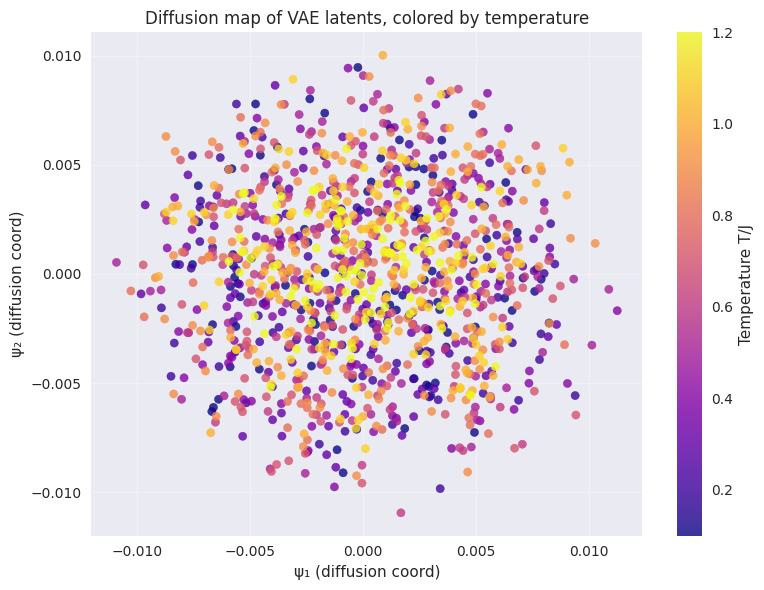

In [10]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(dm_coords[:, 0], dm_coords[:, 1], c=temp_subset, cmap='plasma', s=35, alpha=0.8)
plt.xlabel('ψ₁ (diffusion coord)')
plt.ylabel('ψ₂ (diffusion coord)')
plt.title('Diffusion map of VAE latents, colored by temperature')
plt.grid(True, alpha=0.3)
cbar = plt.colorbar(sc)
cbar.set_label('Temperature T/J')
plt.tight_layout()
plt.show()


/tmp/ipykernel_2823796/1771877088.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_sectors))


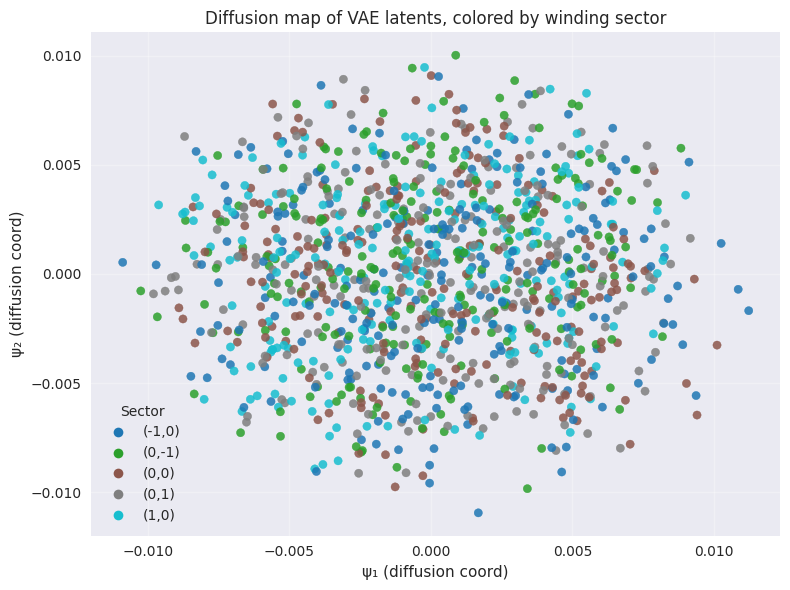

In [11]:
unique_sectors = np.unique(sector_subset)
sector_to_idx = {sec: i for i, sec in enumerate(unique_sectors)}
sector_colors = np.array([sector_to_idx[s] for s in sector_subset], dtype=float)

cmap = plt.cm.get_cmap('tab10', len(unique_sectors))
plt.figure(figsize=(8, 6))
sc = plt.scatter(dm_coords[:, 0], dm_coords[:, 1], c=sector_colors, cmap=cmap, s=35, alpha=0.85)
plt.xlabel('ψ₁ (diffusion coord)')
plt.ylabel('ψ₂ (diffusion coord)')
plt.title('Diffusion map of VAE latents, colored by winding sector')
plt.grid(True, alpha=0.3)
handles = [Line2D([0], [0], marker='o', linestyle='', color=cmap(idx / max(len(unique_sectors) - 1, 1)), label=sec) for sec, idx in sector_to_idx.items()]
plt.legend(handles=handles, title='Sector', loc='best')
plt.tight_layout()
plt.show()
